In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load only the first 1000 images for faster training
(X_train, _), (_, _) = tf.keras.datasets.cifar10.load_data()
X_train = X_train[:1000]  # Use only 1000 images
X_train = X_train / 127.5 - 1.0  # Normalize to [-1, 1]
X_train = X_train.astype(np.float32)

# Build the generator
def build_generator():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(128, input_dim=100),
        tf.keras.layers.LeakyReLU(0.2),
        tf.keras.layers.Dense(256),
        tf.keras.layers.LeakyReLU(0.2),
        tf.keras.layers.Dense(512),
        tf.keras.layers.LeakyReLU(0.2),
        tf.keras.layers.Dense(32 * 32 * 3, activation='tanh'),
        tf.keras.layers.Reshape((32, 32, 3))
    ])
    return model

# Build the discriminator
def build_discriminator():
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(32, 32, 3)),
        tf.keras.layers.Dense(1024),
        tf.keras.layers.LeakyReLU(0.2),
        tf.keras.layers.Dense(512),
        tf.keras.layers.LeakyReLU(0.2),
        tf.keras.layers.Dense(256),
        tf.keras.layers.LeakyReLU(0.2),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    return model

# Compile the models
discriminator = build_discriminator()
discriminator.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(0.0002, 0.5), metrics=['accuracy'])

generator = build_generator()

gan = tf.keras.Sequential([generator, discriminator])
gan.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(0.0002, 0.5))

# Training function with reduced epochs and smaller batch size
def train_gan(epochs, batch_size, save_interval):
    half_batch = batch_size // 2

    for epoch in range(epochs):
        # Train Discriminator
        idx = np.random.randint(0, X_train.shape[0], half_batch)
        real_images = X_train[idx]
        labels_real = np.ones((half_batch, 1))  # Real labels
        fake_images = generator.predict(np.random.randn(half_batch, 100))
        labels_fake = np.zeros((half_batch, 1))  # Fake labels

        # Train on real and fake images
        d_loss_real = discriminator.train_on_batch(real_images, labels_real)
        d_loss_fake = discriminator.train_on_batch(fake_images, labels_fake)
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

        # Train Generator (via GAN)
        noise = np.random.randn(batch_size, 100)
        valid_y = np.ones((batch_size, 1))  # Valid labels for the generator to fool the discriminator
        g_loss = gan.train_on_batch(noise, valid_y)

        # Print progress
        if epoch % save_interval == 0:
            print(f"{epoch} [D loss: {d_loss[0]} | D accuracy: {100*d_loss[1]}] [G loss: {g_loss}]")

            # Save generated image samples
            if epoch % (save_interval * 10) == 0:
                save_generated_images(epoch)

# Save generated images
def save_generated_images(epoch):
    noise = np.random.randn(16, 100)
    generated_images = generator.predict(noise)
    generated_images = 0.5 * generated_images + 0.5  # Rescale to [0, 1]

    fig, axs = plt.subplots(4, 4, figsize=(4, 4))
    cnt = 0
    for i in range(4):
        for j in range(4):
            axs[i, j].imshow(generated_images[cnt])
            axs[i, j].axis('off')
            cnt += 1
    fig.savefig(f"gan_generated_image_epoch_{epoch}.png")
    plt.close()

# Train the GAN on a smaller dataset with fewer epochs
train_gan(epochs=50, batch_size=32, save_interval=200)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


0 [D loss: 0.7060227394104004 | D accuracy: 37.5] [G loss: 0.8148790001869202]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 21.8MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 624kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 5.70MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 5.51MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



Epoch [1/2] | D Loss: 0.4017 | G Loss: 3.0598


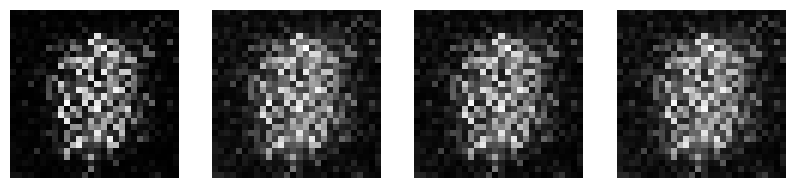

Epoch [2/2] | D Loss: 0.1684 | G Loss: 3.0574


In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Hyperparameters
image_size = 28*28  # MNIST images are 28x28
latent_dim = 100  # Size of noise vector
batch_size = 64
epochs = 2  # Training iterations
lr = 0.0002  # Learning rate

# Define the Generator
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, image_size),
            nn.Tanh()  # Output values between -1 and 1
        )

    def forward(self, z):
        return self.model(z)

# Define the Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(image_size, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 1),
            nn.Sigmoid()  # Output probability of real/fake
        )

    def forward(self, img):
        return self.model(img)

# Initialize models
generator = Generator()
discriminator = Discriminator()

# Loss function & optimizers
criterion = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=lr)
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr)

# Load dataset (MNIST)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.5], [0.5])])
dataset = torchvision.datasets.MNIST(root="./data", train=True, transform=transform, download=True)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Training Loop
for epoch in range(epochs):
    for i, (real_images, _) in enumerate(dataloader):
        real_images = real_images.view(-1, image_size)  # Flatten images
        batch_size = real_images.size(0)

        # Labels for real and fake images
        real_labels = torch.ones(batch_size, 1)
        fake_labels = torch.zeros(batch_size, 1)

        # Train Discriminator
        optimizer_D.zero_grad()
        real_outputs = discriminator(real_images)
        d_loss_real = criterion(real_outputs, real_labels)

        z = torch.randn(batch_size, latent_dim)  # Generate random noise
        fake_images = generator(z)  # Generate fake images
        fake_outputs = discriminator(fake_images.detach())  # Detach to avoid training generator
        d_loss_fake = criterion(fake_outputs, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()

        # Train Generator
        optimizer_G.zero_grad()
        fake_outputs = discriminator(fake_images)  # Try to fool the discriminator
        g_loss = criterion(fake_outputs, real_labels)  # Generator wants output to be 1 (real)
        g_loss.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

    # Show generated images every 10 epochs
    if epoch % 10 == 0:
        z = torch.randn(16, latent_dim)
        fake_images = generator(z).detach().numpy().reshape(-1, 28, 28)
        fig, axes = plt.subplots(1, 4, figsize=(10, 2.5))
        for img, ax in zip(fake_images[:4], axes):
            ax.imshow(img, cmap="gray")
            ax.axis("off")
        plt.show()

# Save the generator model
torch.save(generator.state_dict(), "generator.pth")


In [ ]:
pip install tensorflow numpy matplotlib

In [ ]:
!git clone https://github.com/CompVis/taming-transformers.git
%cd taming-transformers
!pip install -e


Cloning into 'taming-transformers'...
remote: Enumerating objects: 1342, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 1342 (delta 0), reused 0 (delta 0), pack-reused 1341 (from 2)
Receiving objects: 100% (1342/1342), 409.77 MiB | 21.05 MiB/s, done.
Resolving deltas: 100% (282/282), done.
/content/taming-transformers

Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

-e option requires 1 argument


In [ ]:
!pip install torch transformers pillow matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 62.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt


def generate_image(prompt, num_inference_steps=50):
    # Generate image
    with torch.no_grad():
        image = (prompt, num_inference_steps=num_inference_steps).images[0]

    # Show the generated image
    plt.imshow(image)
    plt.axis('off')  # Hide axes
    plt.show()

# Example of generating an image
prompt = ""
generate_image(prompt)


SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (<ipython-input-12-e562451eefb1>, line 9)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 22.0MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 607kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 5.54MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 5.75MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



Epoch [1/2] | D Loss: 0.1206 | G Loss: 4.4051


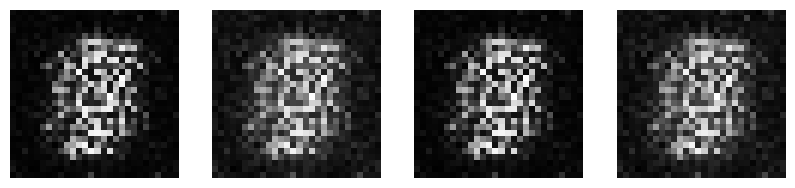

Epoch [2/2] | D Loss: 0.9376 | G Loss: 1.7131


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Hyperparameters
image_size = 28*28  # MNIST images are 28x28
latent_dim = 100  # Size of noise vector
batch_size = 64
epochs = 2  # Training iterations
lr = 0.0002  # Learning rate

# Define the Generator
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, image_size),
            nn.Tanh()  # Output values between -1 and 1
        )

    def forward(self, z):
        return self.model(z)

# Define the Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(image_size, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 1),
            nn.Sigmoid()  # Output probability of real/fake
        )

    def forward(self, img):
        return self.model(img)

# Initialize models
generator = Generator()
discriminator = Discriminator()

# Loss function & optimizers
criterion = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=lr)
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr)

# Load dataset (MNIST)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.5], [0.5])])
dataset = torchvision.datasets.MNIST(root="./data", train=True, transform=transform, download=True)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Training Loop
for epoch in range(epochs):
    for i, (real_images, _) in enumerate(dataloader):
        real_images = real_images.view(-1, image_size)  # Flatten images
        batch_size = real_images.size(0)

        # Labels for real and fake images
        real_labels = torch.ones(batch_size, 1)
        fake_labels = torch.zeros(batch_size, 1)

        # Train Discriminator
        optimizer_D.zero_grad()
        real_outputs = discriminator(real_images)
        d_loss_real = criterion(real_outputs, real_labels)

        z = torch.randn(batch_size, latent_dim)  # Generate random noise
        fake_images = generator(z)  # Generate fake images
        fake_outputs = discriminator(fake_images.detach())  # Detach to avoid training generator
        d_loss_fake = criterion(fake_outputs, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()

        # Train Generator
        optimizer_G.zero_grad()
        fake_outputs = discriminator(fake_images)  # Try to fool the discriminator
        g_loss = criterion(fake_outputs, real_labels)  # Generator wants output to be 1 (real)
        g_loss.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

    # Show generated images every 10 epochs
    if epoch % 10 == 0:
        z = torch.randn(16, latent_dim)
        fake_images = generator(z).detach().numpy().reshape(-1, 28, 28)
        fig, axes = plt.subplots(1, 4, figsize=(10, 2.5))
        for img, ax in zip(fake_images[:4], axes):
            ax.imshow(img, cmap="gray")
            ax.axis("off")
        plt.show()

# Save the generator model
torch.save(generator.state_dict(), "generator.pth")



In [ ]:
pipe = StableDiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-2-1-base", torch_dtype=torch.float32)


model_index.json:   0%|          | 0.00/543 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/911 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.46G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

In [ ]:
pipe = StableDiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-2-1-base")


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

In [ ]:
pip install transformers torch diffusers


Epoch [1/2] | D Loss: 0.5926 | G Loss: 0.8283


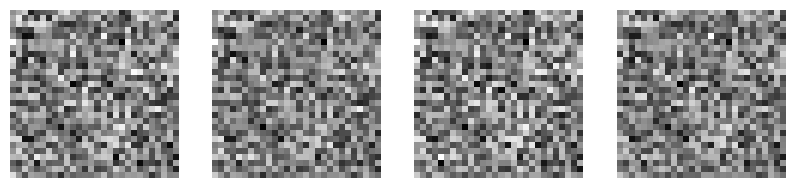

Epoch [2/2] | D Loss: 0.4167 | G Loss: 1.2974


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Hyperparameters
latent_dim = 100
image_size = 28*28  # MNIST images are 28x28
batch_size = 64
epochs = 2
lr = 0.0002

# Generator model
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, image_size),
            nn.Tanh()  # Output between -1 and 1
        )

    def forward(self, z):
        return self.model(z)

# Discriminator model
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(image_size, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 1),
            nn.Sigmoid()  # Output a probability
        )

    def forward(self, img):
        return self.model(img)

# Initialize models
generator = Generator()
discriminator = Discriminator()

# Loss function & optimizers
criterion = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=lr)
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr)

# Training loop (basic GAN)
for epoch in range(epochs):
    for _ in range(100):  # Dummy loop (you can replace this with a real dataset later)
        real_images = torch.randn(batch_size, image_size)  # Fake random real images
        fake_images = generator(torch.randn(batch_size, latent_dim))  # Fake generated images

        # Labels
        real_labels = torch.ones(batch_size, 1)
        fake_labels = torch.zeros(batch_size, 1)

        # Train Discriminator
        optimizer_D.zero_grad()
        real_outputs = discriminator(real_images)
        d_loss_real = criterion(real_outputs, real_labels)

        fake_outputs = discriminator(fake_images.detach())  # Detach to not train generator
        d_loss_fake = criterion(fake_outputs, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()

        # Train Generator
        optimizer_G.zero_grad()
        fake_outputs = discriminator(fake_images)  # Generator tries to fool the discriminator
        g_loss = criterion(fake_outputs, real_labels)
        g_loss.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

    # Save and show generated images
    if epoch % 2 == 0:
        fake_images = fake_images.view(batch_size, 28, 28).detach().numpy()
        fig, axes = plt.subplots(1, 4, figsize=(10, 2.5))
        for img, ax in zip(fake_images[:4], axes):
            ax.imshow(img, cmap="gray")
            ax.axis("off")
        plt.show()


In [ ]:

from diffusers import StableDiffusionPipeline
import torch

# Load the pre-trained model locally
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(model_id).to("cuda" if torch.cuda.is_available() else "cpu")

# Set your prompt
prompt = "A futuristic city at sunset with flying cars"

# Generate the image
image = pipe(prompt).images[0]

# Save and display the image
image.save("generated_image.png")
image.show()


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

...

diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

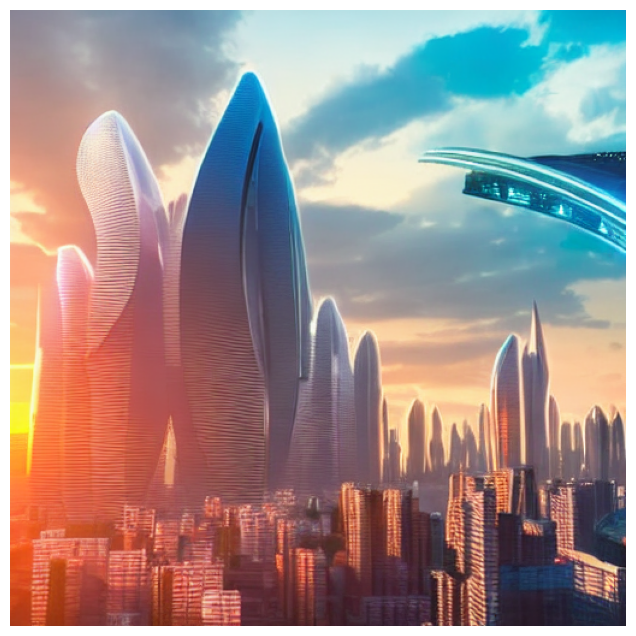

In [ ]:
from diffusers import StableDiffusionPipeline
import torch
import matplotlib.pyplot as plt
from PIL import Image

# Load the pre-trained model locally
model_id = "runwayml/stable-diffusion-v1-5"  # This is the model ID for stable diffusion v1.5
pipe = StableDiffusionPipeline.from_pretrained(model_id).to("cuda" if torch.cuda.is_available() else "cpu")

# Set your prompt
prompt = "A futuristic city at sunset with flying cars"

# Generate the image
image = pipe(prompt).images[0]  # Fetch the first generated image

# Save the image locally
image.save("generated_image.png")

# Show the image in a default viewer
image.show()

# Plot the generated image using matplotlib
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis("off")  # Turn off axis
plt.show()  # Display the image


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

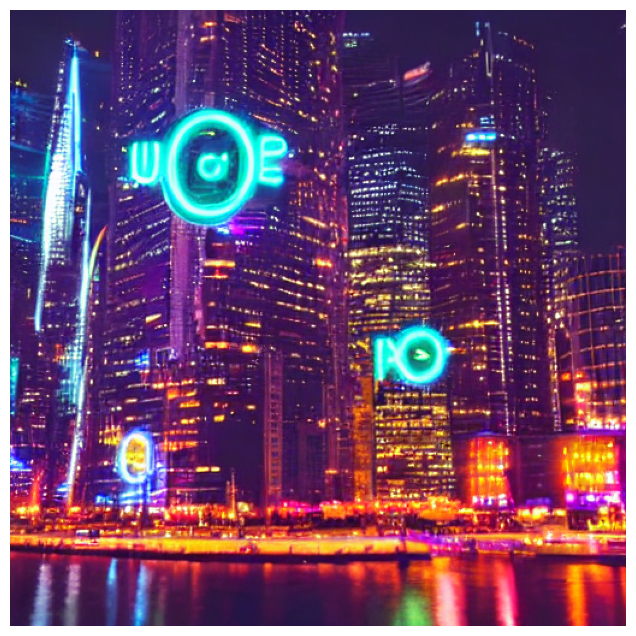

In [ ]:
import matplotlib.pyplot as plt
from diffusers import StableDiffusionPipeline
import torch

# Load the pre-trained model once (to avoid reloading it multiple times)
model_path = "runwayml/stable-diffusion-v1-5"  # Change this to your local model path
pipe = StableDiffusionPipeline.from_pretrained(model_path).to("cuda" if torch.cuda.is_available() else "cpu")

def generate_and_plot(prompt):
    """
    Generates an image from a text prompt using Stable Diffusion and plots it.

    Args:
        prompt (str): The text prompt for image generation.
    """
    # Generate image
    image = pipe(prompt).images[0]

    # Plot the image
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis("off")  # Hide axes
    plt.show()

# Example usage
generate_and_plot("A futuristic city with neon lights at night")

  0%|          | 0/50 [00:00<?, ?it/s]

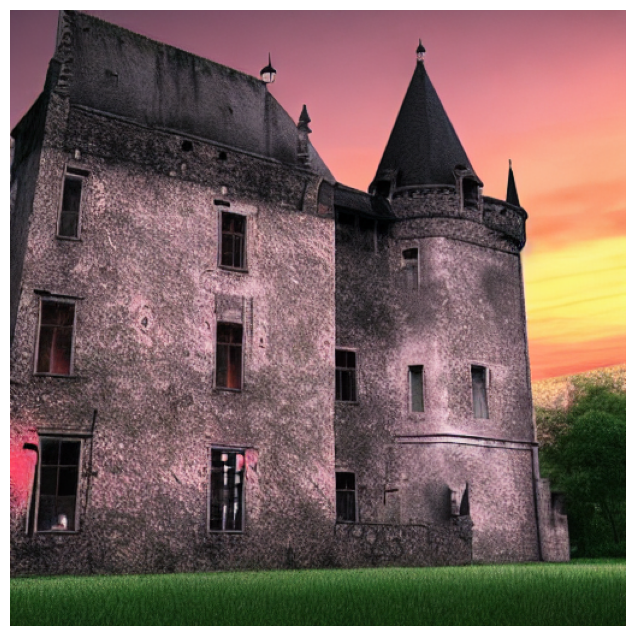

In [ ]:
generate_and_plot("Horror Castel with evening time climate")

  0%|          | 0/50 [00:00<?, ?it/s]

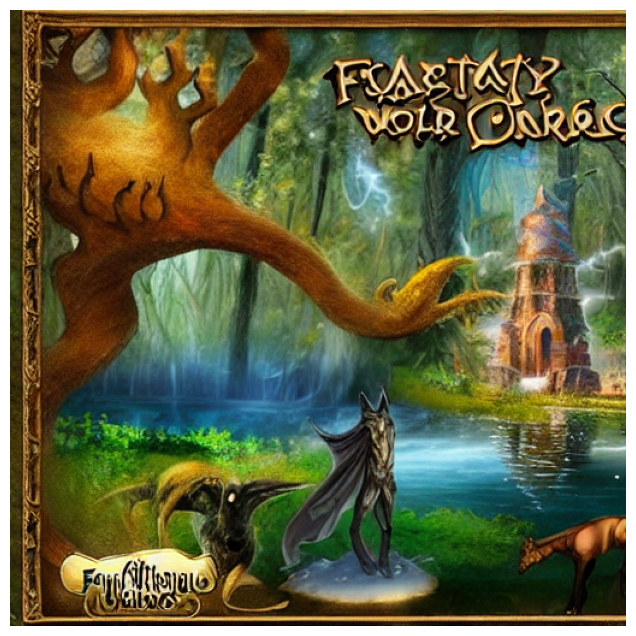

In [ ]:
generate_and_plot("Fantasy world with magical creatures")

Token indices sequence length is longer than the specified maximum sequence length for this model (82 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [', and full of wonder']


  0%|          | 0/50 [00:00<?, ?it/s]

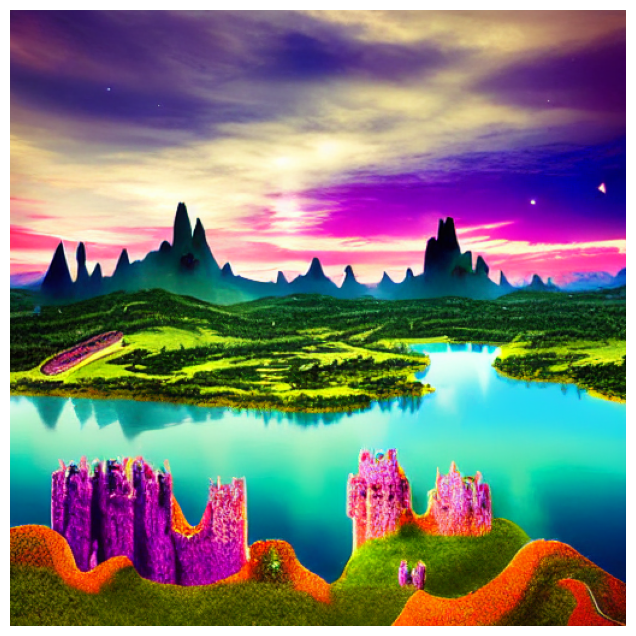

In [ ]:
generate_and_plot("A magical fantasy world with towering castles, floating islands, and glowing rivers. The sky is filled with vibrant, surreal colors like purples, pinks, and oranges, with mythical creatures such as dragons and unicorns soaring through the air. Lush forests and crystal-clear lakes dot the landscape, and distant mountains shimmer with an otherworldly glow. The atmosphere is dreamlike, enchanting, and full of wonder")

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['is dark , filled with swirling clouds and flashes of lightning . a creepy , abandoned graveyard lies nearby , with old tombstones partially covered in moss . figures of ghosts and shadowy entities can be seen in the windows .']


  0%|          | 0/50 [00:00<?, ?it/s]

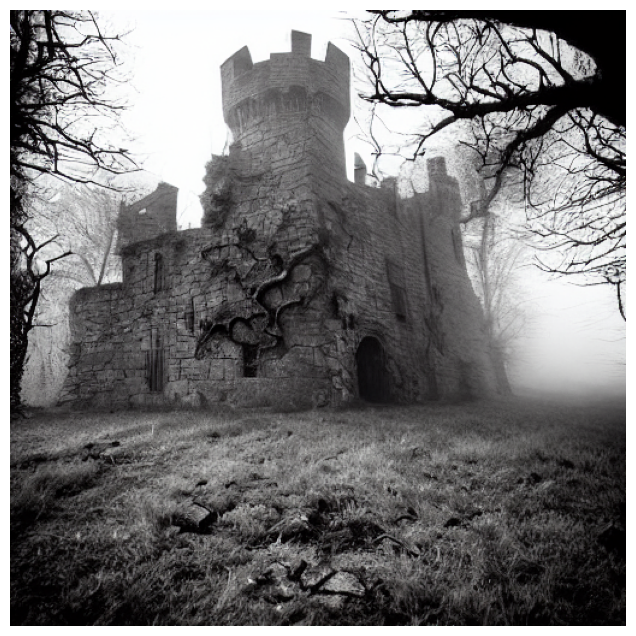

In [ ]:
generate_and_plot("A dark and eerie haunted castle perched atop a fog-covered hill, surrounded by twisted, gnarled trees. The castle’s stone walls are cracked and weathered, with broken windows casting eerie, dim light. Ominous shadows lurk in every corner, and strange mist swirls around the grounds. The atmosphere is heavy with a sense of dread, and the sky is dark, filled with swirling clouds and flashes of lightning. A creepy, abandoned graveyard lies nearby, with old tombstones partially covered in moss. Figures of ghosts and shadowy entities can be seen in the windows.")

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ["’ s cozy aesthetic . neon lights or fairy lights add a playful touch . there 's a stylish clothing rack with trendy outfits , and the floor is covered with a plush rug . the room has a mix of soft neutrals , blush pinks , and subtle metallic accents , creating a chic and instagram - worthy vibe ."]


  0%|          | 0/50 [00:00<?, ?it/s]

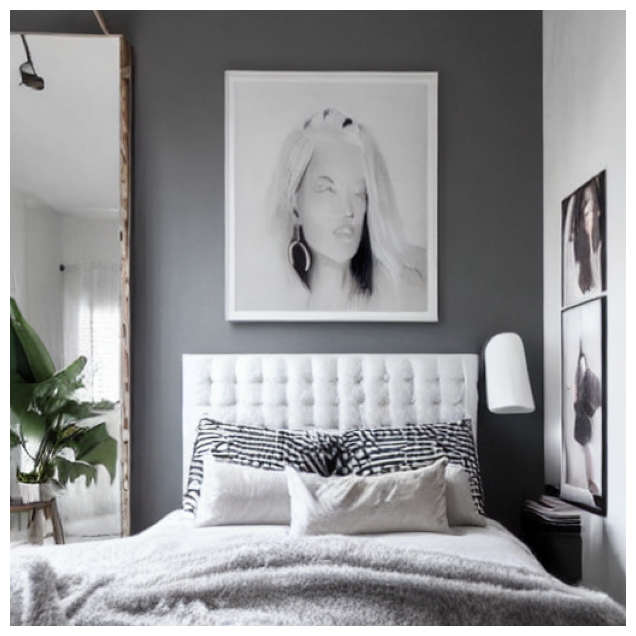

In [ ]:
generate_and_plot(" AI image of A trendy, stylish IT girl’s bedroom with modern minimalist decor. The room features a sleek white bed with fluffy pastel-colored pillows, a soft velvet throw blanket, and a polished wooden desk adorned with a laptop, books, and a chic potted plant. The walls are decorated with framed art prints, motivational quotes, and a large mirror reflecting the room’s cozy aesthetic. Neon lights or fairy lights add a playful touch. There's a stylish clothing rack with trendy outfits, and the floor is covered with a plush rug. The room has a mix of soft neutrals, blush pinks, and subtle metallic accents, creating a chic and Instagram-worthy vibe.")

  0%|          | 0/50 [00:00<?, ?it/s]

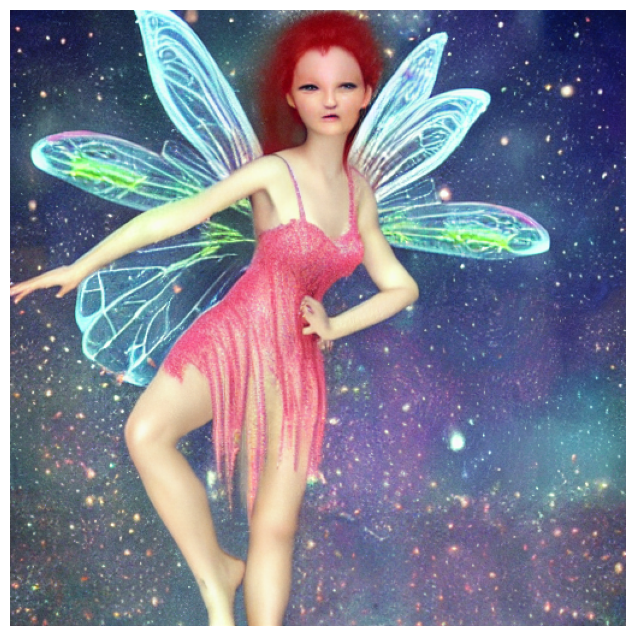

In [ ]:
generate_and_plot("AI Image of a Fairy")

  0%|          | 0/50 [00:00<?, ?it/s]

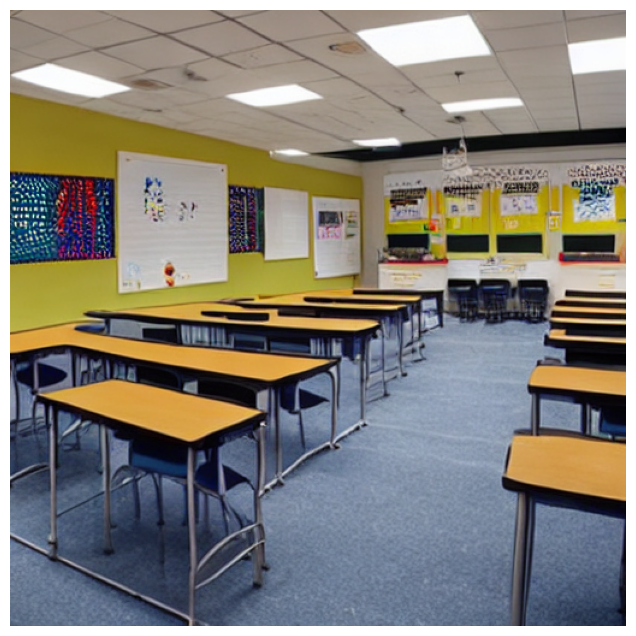

In [ ]:
generate_and_plot("AI image of a school classroom")